In [0]:
from pyspark.sql.functions import col
from pyspark.sql.functions import when
from pyspark.sql.functions import avg
import pandas as pd
import matplotlib.pyplot as plt

data_BASE_DIR = "dbfs:/mnt/mids-w261/"


## Using Joined 2015 1 Month Data

In [0]:
# load dataset

df_otpw_3m = spark.read.csv(f"{data_BASE_DIR}/OTPW_3M_2015.csv", 
    header=True, 
    inferSchema=True)

In [0]:
df_otpw_3m.show(1, vertical=True)

-RECORD 0------------------------------------------------------------
 QUARTER                                      | 1                    
 DAY_OF_MONTH                                 | 10                   
 DAY_OF_WEEK                                  | 6                    
 FL_DATE                                      | 2015-01-10           
 OP_UNIQUE_CARRIER                            | AA                   
 OP_CARRIER_AIRLINE_ID                        | 19805                
 OP_CARRIER                                   | AA                   
 TAIL_NUM                                     | N786AA               
 OP_CARRIER_FL_NUM                            | 2                    
 ORIGIN_AIRPORT_ID                            | 12892                
 ORIGIN_AIRPORT_SEQ_ID                        | 1289203              
 ORIGIN_CITY_MARKET_ID                        | 32575                
 ORIGIN                                       | LAX                  
 ORIGIN_CITY_NAME   

In [0]:
df_otpw_3m.printSchema()

root
 |-- QUARTER: integer (nullable = true)
 |-- DAY_OF_MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- FL_DATE: date (nullable = true)
 |-- OP_UNIQUE_CARRIER: string (nullable = true)
 |-- OP_CARRIER_AIRLINE_ID: integer (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- TAIL_NUM: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: integer (nullable = true)
 |-- ORIGIN_AIRPORT_ID: integer (nullable = true)
 |-- ORIGIN_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- ORIGIN_CITY_MARKET_ID: integer (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- ORIGIN_CITY_NAME: string (nullable = true)
 |-- ORIGIN_STATE_ABR: string (nullable = true)
 |-- ORIGIN_STATE_FIPS: integer (nullable = true)
 |-- ORIGIN_STATE_NM: string (nullable = true)
 |-- ORIGIN_WAC: integer (nullable = true)
 |-- DEST_AIRPORT_ID: integer (nullable = true)
 |-- DEST_AIRPORT_SEQ_ID: integer (nullable = true)
 |-- DEST_CITY_MARKET_ID: integer (nullable = true)
 |-- DEST:

In [0]:
df_otpw_3m.describe().show(vertical=True)

-RECORD 0------------------------------------------------------------
 summary                                      | count                
 QUARTER                                      | 1401363              
 DAY_OF_MONTH                                 | 1401363              
 DAY_OF_WEEK                                  | 1401363              
 OP_UNIQUE_CARRIER                            | 1401363              
 OP_CARRIER_AIRLINE_ID                        | 1401363              
 OP_CARRIER                                   | 1401363              
 TAIL_NUM                                     | 1393176              
 OP_CARRIER_FL_NUM                            | 1401363              
 ORIGIN_AIRPORT_ID                            | 1401363              
 ORIGIN_AIRPORT_SEQ_ID                        | 1401363              
 ORIGIN_CITY_MARKET_ID                        | 1401363              
 ORIGIN                                       | 1401363              
 ORIGIN_CITY_NAME   

In [0]:
# flights per airport
df_otpw_3m.groupBy("ORIGIN_CITY_NAME").count().orderBy("count", ascending=False).show()

+--------------------+-----+
|    ORIGIN_CITY_NAME|count|
+--------------------+-----+
|         Chicago, IL|91659|
|         Atlanta, GA|89632|
|Dallas/Fort Worth...|67215|
|        New York, NY|53644|
|         Houston, TX|53280|
|          Denver, CO|51318|
|     Los Angeles, CA|51045|
|         Phoenix, AZ|39529|
|   San Francisco, CA|37827|
|       Las Vegas, NV|34527|
|         Orlando, FL|30609|
|      Washington, DC|29645|
|         Detroit, MI|28573|
|          Boston, MA|27188|
|     Minneapolis, MN|27066|
|       Charlotte, NC|27024|
|          Newark, NJ|26331|
|  Salt Lake City, UT|25964|
|         Seattle, WA|25386|
| Fort Lauderdale, FL|21677|
+--------------------+-----+
only showing top 20 rows


In [0]:
# flights per airline
df_otpw_3m.groupBy("OP_UNIQUE_CARRIER").count().show()

+-----------------+------+
|OP_UNIQUE_CARRIER| count|
+-----------------+------+
|               UA|117944|
|               NK| 26184|
|               AA|129735|
|               EV|149244|
|               B6| 62778|
|               DL|199348|
|               OO|142142|
|               F9| 19581|
|               US| 98128|
|               MQ| 84967|
|               HA| 18501|
|               AS| 39685|
|               VX| 13818|
|               WN|299308|
+-----------------+------+



In [0]:
df_otpw_3m = df_otpw_3m.withColumn(
    "is_delayed",
    when(df_otpw_3m.DEP_DELAY > 15, 1).otherwise(0)
)

In [0]:
airport_delay_by_airport = df_otpw_3m.groupBy("ORIGIN_CITY_NAME").agg(
    avg("is_delayed").alias("delay_rate")
)

display(airport_delay_by_airport)

ORIGIN_CITY_NAME,delay_rate
"Gainesville, FL",0.17847025495750707
"Ontario, CA",0.1670324846356453
"Richmond, VA",0.16697490092470277
"Tucson, AZ",0.13977042538825118
"Pago Pago, TT",0.25925925925925924
"Myrtle Beach, SC",0.19582504970178927
"Medford, OR",0.14285714285714285
"Palm Springs, CA",0.18215827338129498
"Redding, CA",0.15702479338842976
"Durango, CO",0.18421052631578946


In [0]:
airport_delay_by_airport.toPandas().to_csv("/dbfs/FileStore/EDA_Airport_Rate.csv", index=False)

In [0]:
airport_delay_by_airline = df_otpw_3m.groupBy("OP_UNIQUE_CARRIER").agg(
    avg("is_delayed").alias("delay_rate")
)

display(airport_delay_by_airline)

OP_UNIQUE_CARRIER,delay_rate
UA,0.24110594858576953
NK,0.2422471738466239
AA,0.18660346090106755
EV,0.18088499370158934
B6,0.24322214788620217
DL,0.15353552581415414
OO,0.1809880260584486
F9,0.29926970021960064
US,0.14717511821294635
MQ,0.24976755681617568


In [0]:
airport_delay_by_airline.toPandas().to_csv("/dbfs/FileStore/EDA_Airline_Rates.csv", index=False)

In [0]:
df_otpw_3m.select("DEP_DELAY").describe().show()

+-------+------------------+
|summary|         DEP_DELAY|
+-------+------------------+
|  count|           1359057|
|   mean|10.356973254249086|
| stddev| 37.84557177171765|
|    min|             -61.0|
|    max|            1988.0|
+-------+------------------+



## Using 2022 1 Year Q4 Data

In [0]:
df_flights = spark.read.parquet(f"{data_BASE_DIR}/datasets_final_project_2022/parquet_airlines_data_1y/")
df_flights_q4 = df_flights.filter(col("QUARTER") == 4)

In [0]:
df_flights_q4 = df_flights_q4.withColumn(
    "is_delayed",
    when(df_flights_q4.DEP_DELAY > 15, 1).otherwise(0)
)

In [0]:
airport_delay_by_airport = df_flights_q4.groupBy("ORIGIN_CITY_NAME").agg(
    avg("is_delayed").alias("delay_rate")
)

display(airport_delay_by_airport)

ORIGIN_CITY_NAME,delay_rate
"Gainesville, FL",0.12841328413284134
"Richmond, VA",0.14678747940691927
"Tucson, AZ",0.13928074706934235
"Ontario, CA",0.14403973509933773
"Pierre, SD",0.14534883720930233
"Pago Pago, TT",0.2857142857142857
"Myrtle Beach, SC",0.15111695137976347
"Medford, OR",0.15165511932255582
"Palm Springs, CA",0.17038269550748752
"Redding, CA",0.2098092643051771


In [0]:
airport_delay_df = airport_delay_by_airport.toPandas()

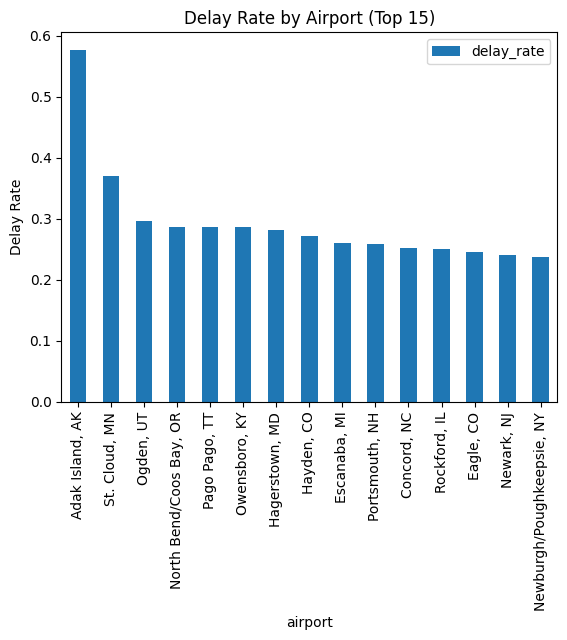

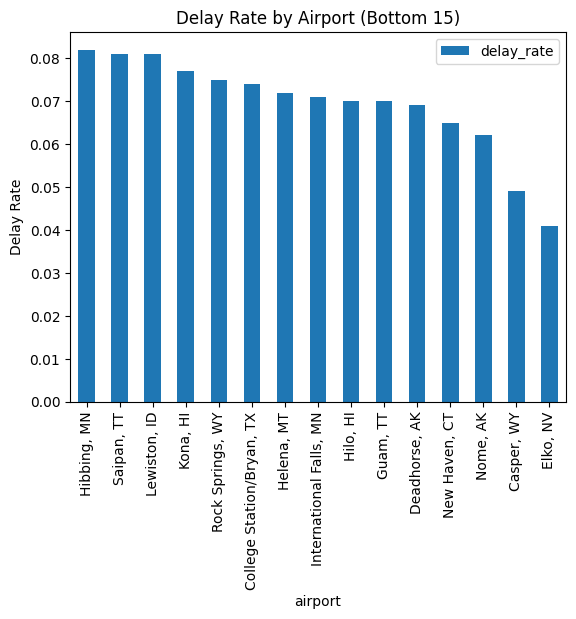

In [0]:
airport_delay_df = airport_delay_df.round(3)
airport_delay_df.columns = ["airport", "delay_rate"]

top_airlines = (
    airport_delay_df.sort_values("delay_rate", ascending=False)
      .head(15)
)
top_airlines.plot.bar(x="airport", y="delay_rate")
plt.title("Delay Rate by Airport (Top 15)")
plt.ylabel("Delay Rate")
plt.show()

bottom_airlines = (
    airport_delay_df.sort_values("delay_rate", ascending=False)
      .tail(15)
)
bottom_airlines.plot.bar(x="airport", y="delay_rate")
plt.title("Delay Rate by Airport (Bottom 15)")
plt.ylabel("Delay Rate")
plt.show()

In [0]:
airport_delay_by_airline = df_flights_q4.groupBy("OP_UNIQUE_CARRIER").agg(
    avg("is_delayed").alias("delay_rate")
)

display(airport_delay_by_airline)

OP_UNIQUE_CARRIER,delay_rate
UA,0.15694528729758217
NK,0.14633674101610905
AA,0.15679057475031408
EV,0.1814551772487579
B6,0.2269003034069797
DL,0.11903570909912381
OO,0.15441606459036802
F9,0.22800096610578857
YV,0.1897607220317638
MQ,0.14280252577573874


In [0]:
airline_delay_df = airport_delay_by_airline.toPandas()

In [0]:
airline_delay_df = airline_delay_df.round(3)
airline_delay_df.columns = ["airline_unique_carrier", "delay_rate"]

carrier_map = {
    "F9": "Frontier Airlines",
    "MQ": "Envoy Air",
    "B6": "JetBlue Airways",
    "NK": "Spirit Airlines",
    "UA": "United Airlines",
    "WN": "Southwest Airlines",
    "AA": "American Airlines",
    "OO": "SkyWest Airlines",
    "EV": "ExpressJet Airlines",
    "DL": "Delta Air Lines",
    "AS": "Alaska Airlines",
    "HA": "Hawaiian Airlines",
    "YV": "Mesa Airlines",
    "OH": "PSA Airlines",
    "G4": "Allegiant Air",
    "YX": "Republic Airways",
    "9E": "Endeavor Air"
}

airline_delay_df["airline"] = airline_delay_df["airline_unique_carrier"].map(carrier_map)
airline_delay_df = airline_delay_df.sort_values('delay_rate', ascending=False)

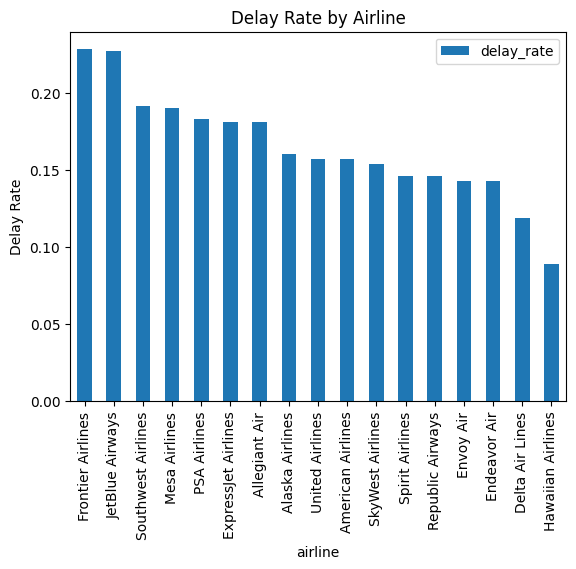

In [0]:
airline_delay_df.plot.bar(x="airline", y="delay_rate")
plt.title("Delay Rate by Airline")
plt.ylabel("Delay Rate")
plt.show()

In [0]:
df_flights_q4.describe().show(vertical=True)

-RECORD 0---------------------------------------
 summary                 | count                
 QUARTER                 | 3728460              
 MONTH                   | 3728460              
 DAY_OF_MONTH            | 3728460              
 DAY_OF_WEEK             | 3728460              
 FL_DATE                 | 3728460              
 OP_UNIQUE_CARRIER       | 3728460              
 OP_CARRIER_AIRLINE_ID   | 3728460              
 OP_CARRIER              | 3728460              
 TAIL_NUM                | 3725616              
 OP_CARRIER_FL_NUM       | 3728460              
 ORIGIN_AIRPORT_ID       | 3728460              
 ORIGIN_AIRPORT_SEQ_ID   | 3728460              
 ORIGIN_CITY_MARKET_ID   | 3728460              
 ORIGIN                  | 3728460              
 ORIGIN_CITY_NAME        | 3728460              
 ORIGIN_STATE_ABR        | 3728460              
 ORIGIN_STATE_FIPS       | 3728460              
 ORIGIN_STATE_NM         | 3728460              
 ORIGIN_WAC         

In [0]:
from pyspark.sql.functions import quarter, expr, min, max, stddev, mean, lit

df_weather = spark.read.parquet(f"dbfs:/mnt/mids-w261/datasets_final_project_2022/parquet_weather_data_1y/")
df_weather_q4 = df_weather.filter(quarter(col("DATE")) == 4)

In [0]:
df_weather_q4.describe().show(vertical=True)

-RECORD 0------------------------------------------------------------
 summary                                      | count                
 STATION                                      | 33487589             
 DATE                                         | 33487589             
 LATITUDE                                     | 33288843             
 LONGITUDE                                    | 33288843             
 ELEVATION                                    | 33288843             
 NAME                                         | 33288843             
 REPORT_TYPE                                  | 33487589             
 SOURCE                                       | 33487589             
 HourlyAltimeterSetting                       | 17140654             
 HourlyDewPointTemperature                    | 27796321             
 HourlyDryBulbTemperature                     | 32786703             
 HourlyPrecipitation                          | 4343327              
 HourlyPresentWeathe

In [0]:
# List files in the folder
folder_path = "dbfs:/mnt/mids-w261/datasets_final_project_2022"
files = dbutils.fs.ls(folder_path)

# Print file names
for f in files:
    print(f.name)

parquet_airlines_data/
parquet_airlines_data_1y/
parquet_airlines_data_3m/
parquet_airlines_data_6m/
parquet_weather_data/
parquet_weather_data_1y/
parquet_weather_data_3m/
parquet_weather_data_6m/
stations_data/


In [0]:

df_weather = spark.read.parquet(f"dbfs:/mnt/mids-w261/datasets_final_project_2022/parquet_weather_data_1y/")
df = df_weather.filter(quarter(col("DATE")) == 4)

# Number of rows
num_rows = df.count()

# Number of columns
num_cols = len(df.columns)

print(f"Rows: {num_rows}, Columns: {num_cols}")

Rows: 33487589, Columns: 124


In [0]:
df_flights = spark.read.parquet(f"{data_BASE_DIR}/datasets_final_project_2022/parquet_airlines_data_1y/")
df = df_flights.filter(col("QUARTER") == 4)

# Number of rows
num_rows = df.count()

# Number of columns
num_cols = len(df.columns)

print(f"Rows: {num_rows}, Columns: {num_cols}")

Rows: 3728460, Columns: 109
